In [ ]:
!pip install nltk
!pip install gensim
!pip install numpy
!pip install contractions
!pip install gradio

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from tensorflow.keras.callbacks import EarlyStopping
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Assignment/train_racist.csv')

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Total samples: 31962
label
0    29720
1     2242
Name: count, dtype: int64


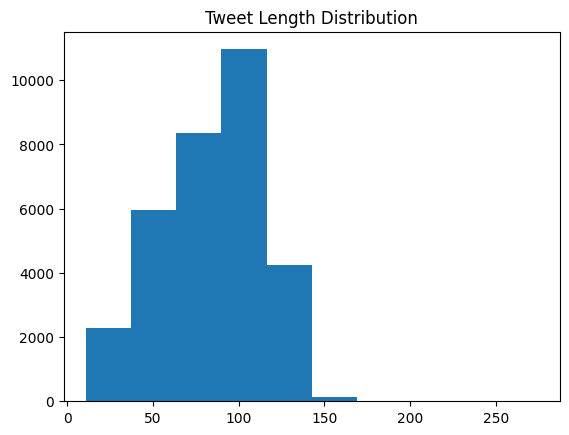

In [ ]:
print("Total samples:", len(df))
print(df['label'].value_counts())

df['tweet_length'] = df['tweet'].apply(len)

plt.hist(df['tweet_length'])
plt.title("Tweet Length Distribution")
plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['tweet'].apply(clean_text)

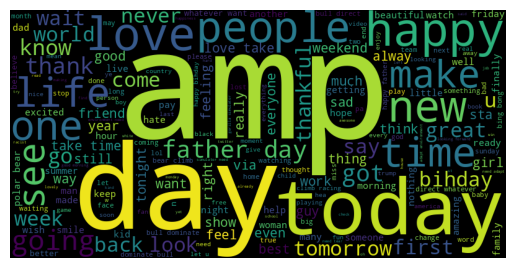

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400).generate(text)
plt.imshow(wc)
plt.axis('off')
plt.show()

In [ ]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 95))
print(f"Using max_len={max_len} (95th percentile)")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

vocab_size = len(tokenizer.word_index) + 1

Using max_len=11 (95th percentile)


In [ ]:
model_rnn = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(X_train_pad, y_train, epochs=5,
                           validation_data=(X_test_pad, y_test),
                           callbacks=[EarlyStopping(patience=2)])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.9405 - loss: 0.2000 - val_accuracy: 0.9453 - val_loss: 0.1653
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9706 - loss: 0.0869 - val_accuracy: 0.9504 - val_loss: 0.1958
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9873 - loss: 0.0399 - val_accuracy: 0.9437 - val_loss: 0.2364


In [ ]:
model_lstm = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train_pad, y_train, epochs=5,
                             validation_data=(X_test_pad, y_test),
                             callbacks=[EarlyStopping(patience=2)])


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9393 - loss: 0.1971 - val_accuracy: 0.9454 - val_loss: 0.1620
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9627 - loss: 0.1096 - val_accuracy: 0.9481 - val_loss: 0.1677
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.9743 - loss: 0.0783 - val_accuracy: 0.9448 - val_loss: 0.1837


In [ ]:
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

model_w2v = Sequential([
    Embedding(vocab_size, embedding_dim, weights=[embedding_matrix],
              input_length=max_len, trainable=False),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v = model_w2v.fit(X_train_pad, y_train, epochs=5,
                           validation_data=(X_test_pad, y_test),
                           callbacks=[EarlyStopping(patience=2)])


Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9320 - loss: 0.2120 - val_accuracy: 0.9349 - val_loss: 0.1958
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9385 - loss: 0.1820 - val_accuracy: 0.9388 - val_loss: 0.1871
Epoch 3/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9443 - loss: 0.1654 - val_accuracy: 0.9409 - val_loss: 0.1774
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9481 - loss: 0.1514 - val_accuracy: 0.9445 - val_loss: 0.1731
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9544 - loss: 0.1400 - val_accuracy: 0.9437 - val_loss: 0.1743


In [ ]:
def get_metrics(model):
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    }

results = pd.DataFrame([
    get_metrics(model_rnn),
    get_metrics(model_lstm),
    get_metrics(model_w2v)
], index=["RNN", "LSTM", "Word2Vec"])

print(results)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
          Accuracy  Precision    Recall        F1
RNN       0.943688   0.658147  0.448802  0.533679
LSTM      0.944783   0.640957  0.525054  0.577246
Word2Vec  0.943688   0.712446  0.361656  0.479769


In [ ]:
from sklearn.metrics import classification_report
for model, name in [(model_rnn, 'RNN'), (model_lstm, 'LSTM'), (model_w2v, 'Word2Vec')]:
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, preds))

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== RNN Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5934
           1       0.66      0.45      0.53       459

    accuracy                           0.94      6393
   macro avg       0.81      0.72      0.75      6393
weighted avg       0.94      0.94      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== LSTM Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5934
           1       0.64      0.53      0.58       459

    accuracy                           0.94      6393
   macro avg       0.80      0.75      0.77      6393
weighted avg       0.94      0.94      0.94      6393

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Word2Vec Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5934
      

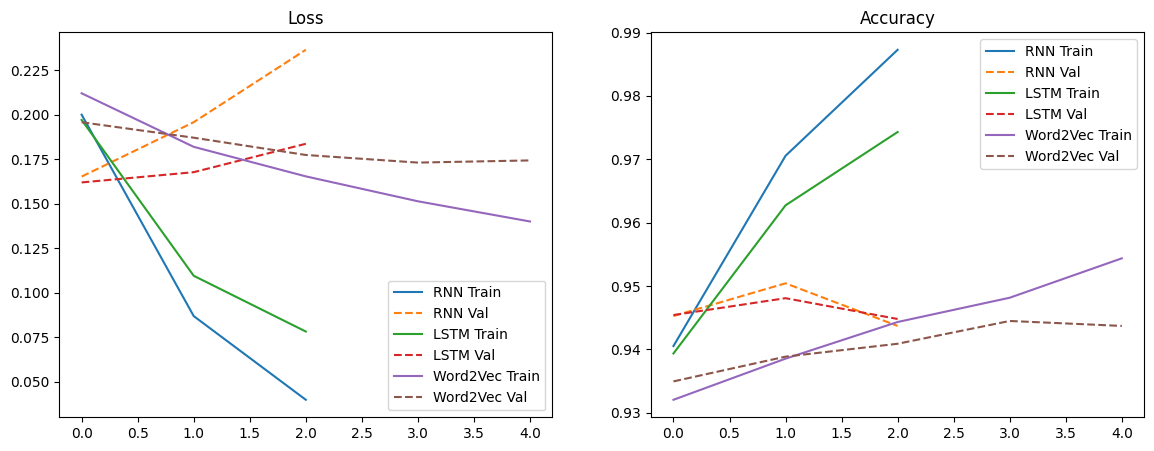

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for history, label in [(history_rnn, 'RNN'), (history_lstm, 'LSTM'), (history_w2v, 'Word2Vec')]:
    axes[0].plot(history.history['loss'], label=f'{label} Train')
    axes[0].plot(history.history['val_loss'], linestyle='--', label=f'{label} Val')
    axes[1].plot(history.history['accuracy'], label=f'{label} Train')
    axes[1].plot(history.history['val_accuracy'], linestyle='--', label=f'{label} Val')
axes[0].set_title('Loss'); axes[0].legend()
axes[1].set_title('Accuracy'); axes[1].legend()
plt.show()

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


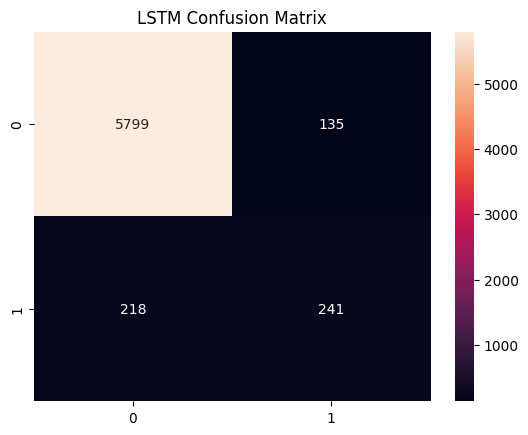

In [ ]:
preds = (model_lstm.predict(X_test_pad) > 0.5).astype(int)
cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")
plt.show()


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


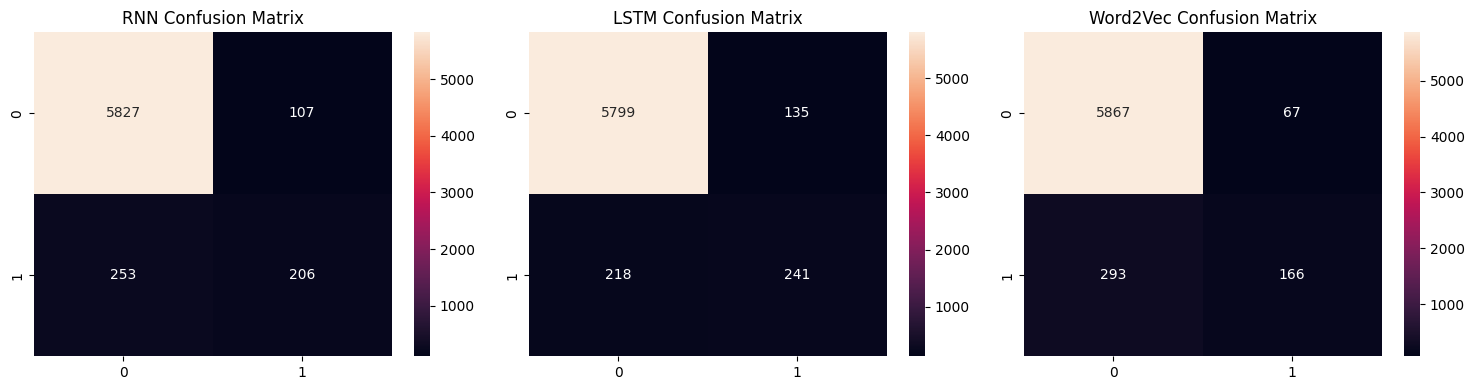

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model, name in zip(axes, [model_rnn, model_lstm, model_w2v], ['RNN', 'LSTM', 'Word2Vec']):
    preds = (model.predict(X_test_pad) > 0.5).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
errors = []

preds = (model_lstm.predict(X_test_pad) > 0.5).astype(int)

for i in range(len(preds)):
    if preds[i] != y_test.iloc[i]:
        errors.append((X_test.iloc[i], y_test.iloc[i], preds[i]))

for i in range(3):
    print(errors[i])


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
('h p p', np.int64(0), array([1]))
('wi book full algerian rhetoric w issue pity', np.int64(0), array([1]))
('color human skin matter lot system come judgement call', np.int64(0), array([1]))


## Error Analysis

**Possible reasons for misclassification:**
- Short or ambiguous tweets without clear sentiment markers
- Sarcasm or irony not captured by the model
- Rare words not covered by the GloVe vocabulary (OOV words)

**Model Complexity vs. Performance:**
- Simple RNN struggles with long-range dependencies
- LSTM handles sequential memory better but still limited by max_len
- Word2Vec LSTM benefits from pretrained semantics but frozen embeddings can't adapt

**Suggested Improvements:**
- Fine-tune embeddings (set trainable=True)
- Use bidirectional LSTM
- Increase vocabulary size or use subword tokenization
- Add more training data or use data augmentation

In [ ]:
import gradio as gr

def predict_tweet(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len)
    pred = model_lstm.predict(padded)[0][0]
    return "Racist/Sexist 🔴" if pred > 0.5 else "Non-Racist/Sexist ✅"

gr.Interface(fn=predict_tweet, inputs="text", outputs="text",
             title="Tweet Sentiment Classifier").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c3f54a6de28a9af8d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
